In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import graph_tool.all as gt
import numpy as np
import torch
from torch_geometric.utils import to_networkx, stochastic_blockmodel_graph
from torch_geometric.data import Data
from src.datasets import DataSplit
import src.utils as ut
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


In [2]:
def count_probs(data, communities):
    G = to_networkx(data, to_undirected=True)
    probs = np.zeros((len(communities), len(communities)))
    sizes = []
    block = np.empty((len(G.nodes)))
    for idx, c in enumerate(communities):
        sizes.append(len(c))
        for n in c:
            block[n] = idx
            G.nodes[n]["com"] = idx  # get com label
    for u, v in zip(
        data.edge_index[0], data.edge_index[1]
    ):  # count number of edge per com
        u = float(u)
        v = float(v)
        probs[G.nodes[u]["com"], G.nodes[v]["com"]] += 1
    for x in range(len(probs)):  # make the probs
        for y in range(len(probs)):
            if x == y:
                if sizes[x] > 1:
                    probs[x, x] = (
                        probs[x, x] / ((sizes[x] * (sizes[x] - 1)) / 2)
                    )
            else:
                probs[x, y] /= ((
                    (sizes[x] + sizes[y]) * (sizes[x] + sizes[y] - 1)
                ) / 2)  # complete graph formula
    probs /= 2  # undirected graph
    data.block = block
    data.communities = communities
    data.probs = probs
    # print("probs, ", probs)
    data.sizes = sizes
    # print("sizes, ", sizes)
    return data

1 split from the dataset synthetic_1


100%|██████████| 1/1 [00:00<00:00,  6.09it/s]


split time:  0.17  s
data:  Data(edge_index=[2, 2038], block=[400], partition=[5], name='stochastic_block_model', num_nodes=400, sizes=[5], probs=[5, 5], num_features=400, x=[400, 400], adj_t=[400, 400, nnz=2038], max_x=-1, full_adj_t=[400, 400, nnz=2328])
dataset split 
train edge 1019
valid edge 145
valid edge_neg 145
test edge 290
test edge_neg 290


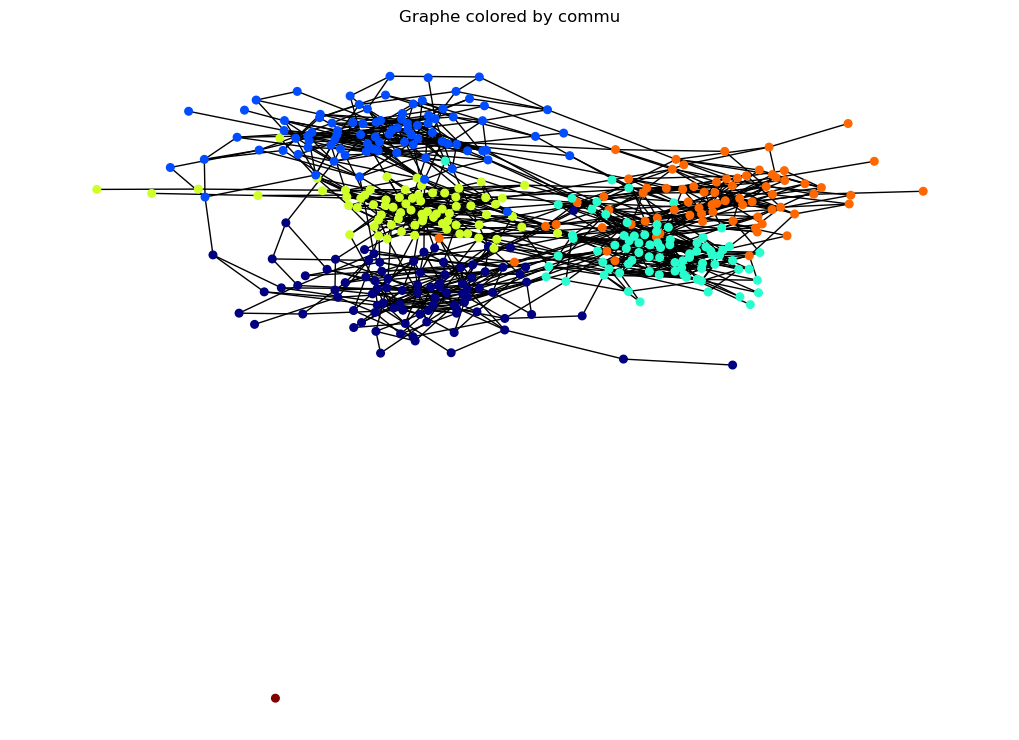

In [2]:
data_split = DataSplit('synthetic_1', device, 1)
data, split = data_split.get(0)
data = ut.commu_repartition(data, 'louvain')
communities = data.communities
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = i
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G, seed=42)
node_colors = [color_map[node] for node in G.nodes()]

plt.figure(figsize=(10, 7))
nx.draw(G, node_size=30, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(communities)))
plt.title("Graphe colored by commu")
plt.show()

In [4]:
node_list = {}
for idx, bl in enumerate(data.block):
    node_list[idx] = bl

sorted_dict = {key: value for key, 
               value in sorted(node_list.items(), 
                               key=lambda item: item[1])}

node_list = list(sorted_dict.keys())

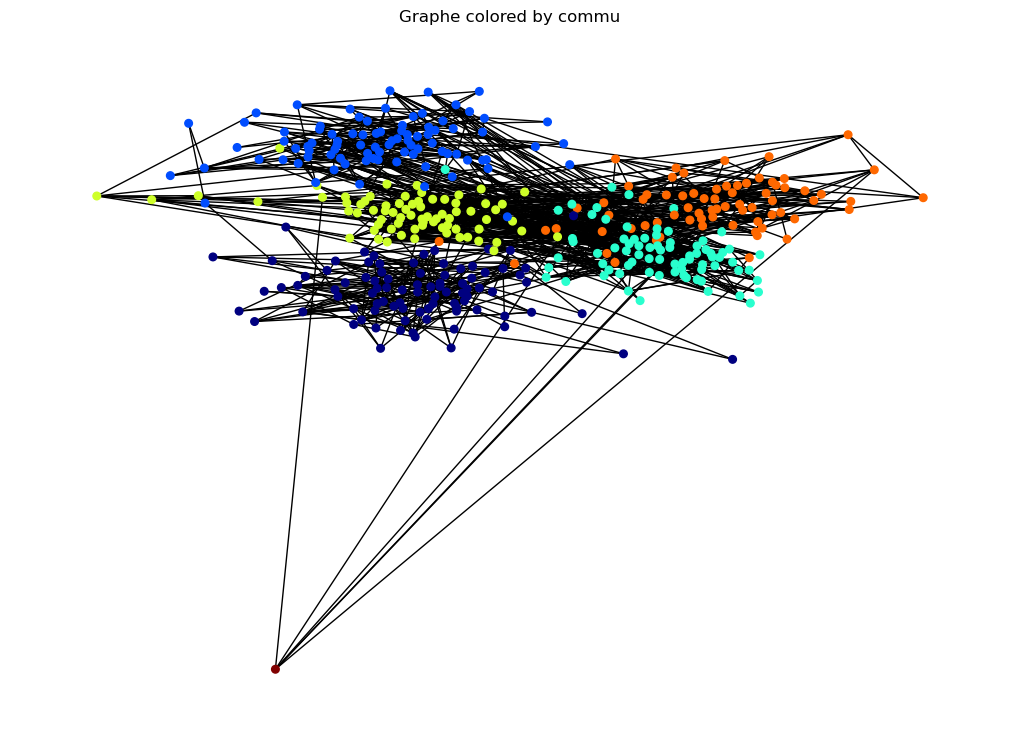

torch.Size([2, 1848])


In [5]:
data_sbm = ut.gen_sbm(data.sizes, data.probs, node_list)
G_sbm = to_networkx(data_sbm, to_undirected=True)
plt.figure(figsize=(10, 7))
nx.draw(G_sbm, node_size=30, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(communities)))
plt.title("Graphe colored by commu")
plt.show()
print(data_sbm.edge_index.shape)

In [6]:
data.probs

array([[5.19350811e-02, 3.57142857e-04, 4.32869201e-04, 2.21729490e-04,
        5.75109271e-04],
       [3.57142857e-04, 4.97948016e-02, 6.43793077e-04, 3.10559006e-04,
        2.82189793e-04],
       [4.32869201e-04, 6.43793077e-04, 6.42515379e-02, 8.71383757e-05,
        2.26736804e-04],
       [2.21729490e-04, 3.10559006e-04, 8.71383757e-05, 6.70270270e-02,
        3.26157860e-04],
       [5.75109271e-04, 2.82189793e-04, 2.26736804e-04, 3.26157860e-04,
        7.74647887e-02]])

In [7]:
data.sizes

[90, 86, 77, 75, 72]

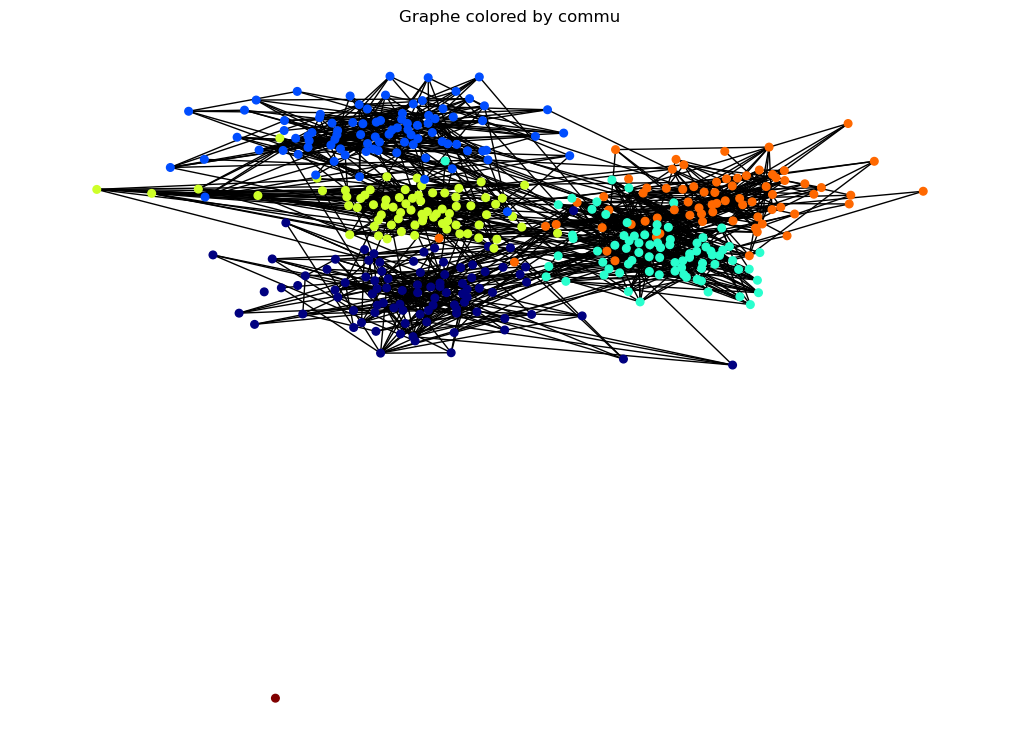

torch.Size([2, 2038])


In [13]:
from torch_geometric.utils import to_undirected
gtG, block_map = ut.to_graph_tool(data)
state = gt.BlockState(gtG, block_map, deg_corr=False)
gtG = state.sample_graph(max_ent=True, self_loops=False, multigraph=False)
edge_index = torch.from_numpy(gtG.get_edges().T)
new_data = Data(edge_index=edge_index).to(data.edge_index.device)
new_data.edge_index = to_undirected(new_data.edge_index)
new_data.num_nodes = sum(data.sizes)
new_data.sizes = data.sizes
new_data.probs = data.probs
new_data.num_features = data.num_nodes

G_sbm_fast = to_networkx(new_data, to_undirected=True)
plt.figure(figsize=(10, 7))
nx.draw(G_sbm_fast, node_size=30, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(communities)))
plt.title("Graphe colored by commu")
plt.show()
print(new_data.edge_index.shape)

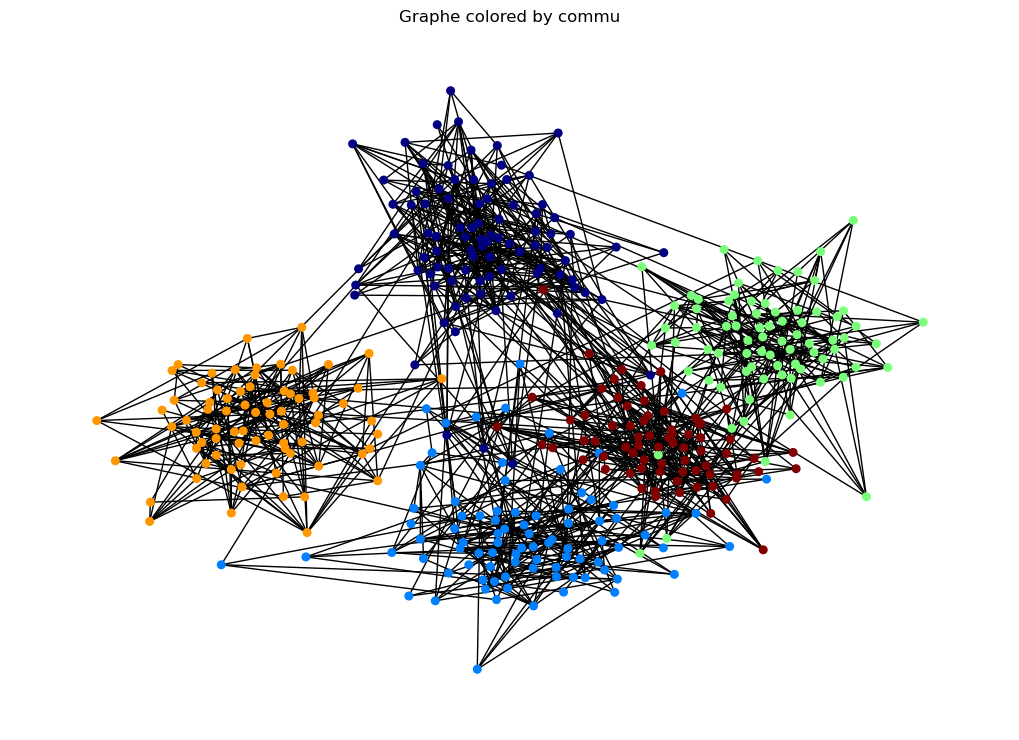

torch.Size([2, 2060])


In [9]:

gtG, block_map = ut.to_graph_tool(data)
state = gt.BlockState(gtG, block_map, deg_corr=False)
data.block = state.b.a
data.probs = gt.adjacency(state.get_bg(), state.get_ers()).T
data.out_degs = gtG.degree_property_map("out").a

data_sbm_fast = ut.gen_sbm_fast(data)

G_sbm_fast = to_networkx(data_sbm_fast, to_undirected=True)
plt.figure(figsize=(10, 7))
nx.draw(G_sbm_fast, node_size=30, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(communities)))
plt.title("Graphe colored by commu")
plt.show()
print(data_sbm_fast.edge_index.shape)

In [10]:
float_formatter = "{:.5f}".format
np.set_printoptions(formatter={'float_kind':float_formatter})

In [11]:
data = count_probs(data, data.communities)
data_sbm = count_probs(data_sbm, data.communities)
data_sbm_fast = count_probs(data_sbm_fast, data.communities)
data.probs - data_sbm_fast.probs

array([[-0.00799, 0.00000, 0.00007, 0.00004, -0.00012],
       [0.00000, -0.00164, 0.00015, 0.00027, 0.00008],
       [0.00007, 0.00015, 0.00308, 0.00004, -0.00005],
       [0.00004, 0.00027, 0.00004, -0.00072, 0.00005],
       [-0.00012, 0.00008, -0.00005, 0.00005, 0.01526]])

In [12]:
data.probs - data_sbm.probs

array([[0.00599, -0.00042, 0.00040, 0.00004, -0.00215],
       [-0.00042, 0.00027, -0.00064, 0.00004, 0.00000],
       [0.00040, -0.00064, 0.02290, -0.00196, 0.00005],
       [0.00004, 0.00004, -0.00196, 0.01586, -0.00252],
       [-0.00215, 0.00000, 0.00005, -0.00252, 0.02426]])

In [13]:
data.sizes

[90, 86, 77, 75, 72]